In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

uploaded = files.upload()  # ← هنا بيطلب منك ترفعي الـ CSV

df = pd.read_csv('tech_mental_health_burnout (1).csv')
df.head()

Saving tech_mental_health_burnout (1).csv to tech_mental_health_burnout (1) (1).csv


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [6]:
# 1. Reading the uploaded dataset
import pandas as pd

# Reading the file
df = pd.read_csv('tech_mental_health_burnout (1).csv')

print("Data loaded successfully!")
print(f"Total records: {df.shape[0]}")
df.head()

Data loaded successfully!
Total records: 150000


,age,gender,job_role,experience_years,company_size,work_mode,work_hours_per_week,overtime_hours,meetings_per_day,deadlines_missed,...,screen_time_hours,caffeine_intake,social_support_score,has_therapy,stress_level,anxiety_score,depression_score,burnout_score,burnout_level,seeks_professional_help
0,50,Female,Backend Developer,7.8,Large,Hybrid,45.0,0.0,5.0,0,...,8.6,1,4.4,0,4.8,4.3,2.6,1.0,Low,0
1,36,Male,Frontend Developer,1.8,Mid-size,Remote,56.0,4.0,6.0,0,...,11.5,4,4.1,0,6.7,4.8,4.6,3.7,Moderate,0
2,29,Male,DevOps,2.5,MNC,Hybrid,43.0,2.0,6.0,3,...,6.8,3,6.5,0,4.5,4.0,2.5,1.0,Low,0
3,42,Female,Backend Developer,1.5,Mid-size,Hybrid,57.0,9.0,4.0,1,...,10.2,5,2.5,0,6.1,5.8,1.8,3.6,Moderate,0
4,40,Female,Frontend Developer,3.4,Large,Remote,49.0,0.0,3.0,4,...,11.9,5,4.6,0,7.2,5.9,2.4,3.5,Low,0


In [7]:
# 2. Dropping the suspicious column to ensure model integrity
if 'burnout_score' in df.columns:
    df = df.drop(['burnout_score'], axis=1)
    print("Column 'burnout_score' has been dropped to prevent Data Leakage.")

# Check if there are any missing values
print(f"Missing values check: {df.isnull().sum().sum()}")

Column 'burnout_score' has been dropped to prevent Data Leakage.
Missing values check: 0


In [8]:
# 2. Dropping the suspicious column to ensure model integrity
if 'burnout_score' in df.columns:
    df = df.drop(['burnout_score'], axis=1)
    print("Column 'burnout_score' has been dropped to prevent Data Leakage.")

# Check if there are any missing values
print(f"Missing values check: {df.isnull().sum().sum()}")

Missing values check: 0


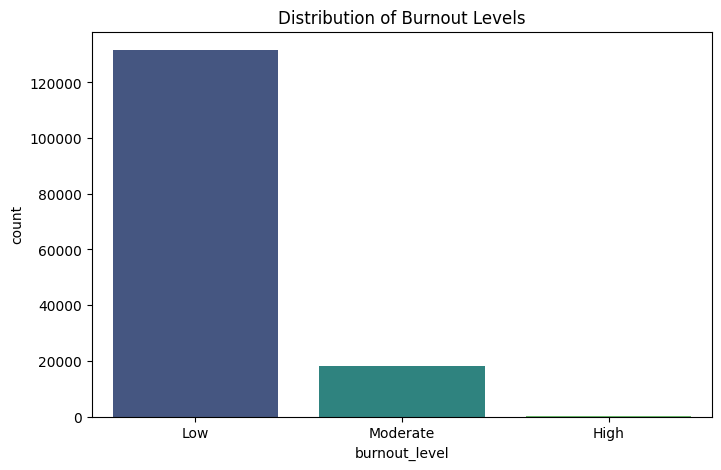

/tmp/ipykernel_950/528442507.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='burnout_level', y='work_hours_per_week', data=df, palette='Set2')


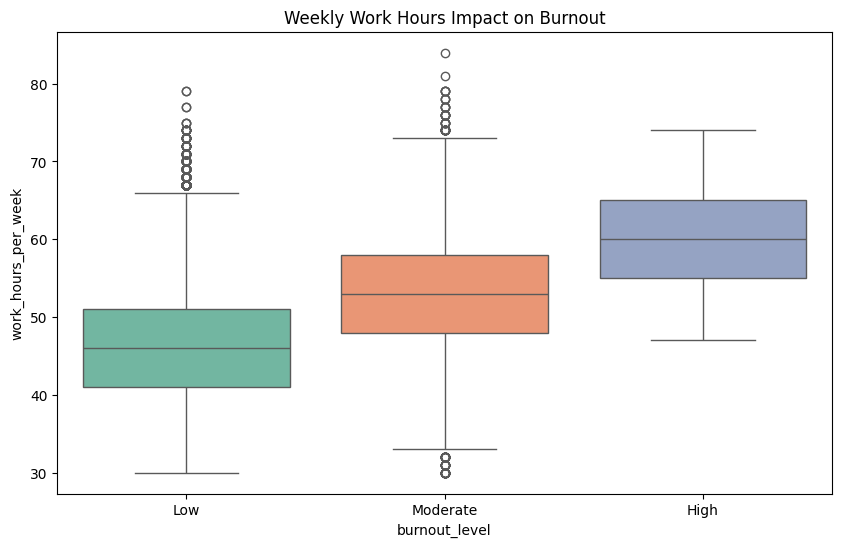

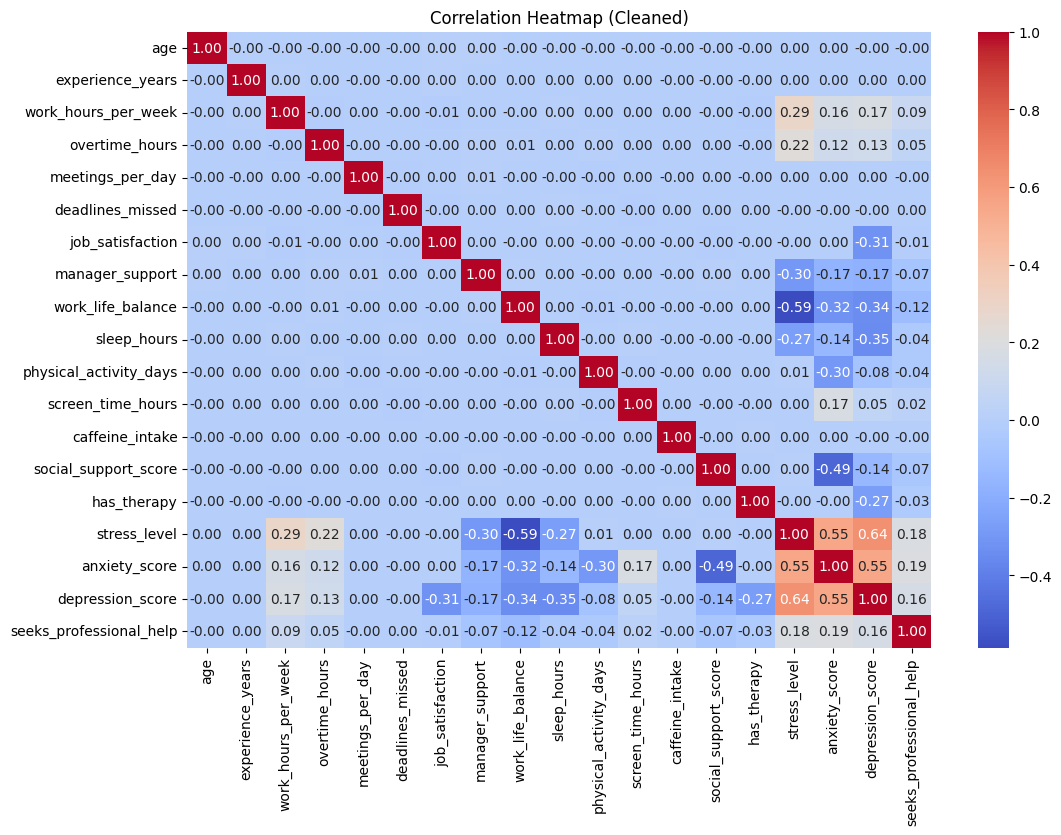

In [9]:
# 3. Exploratory Data Analysis (Visualizations)
import matplotlib.pyplot as plt
import seaborn as sns

# Visual A: Distribution of Burnout Levels (Target)
plt.figure(figsize=(8, 5))
sns.countplot(x='burnout_level', data=df, hue='burnout_level', palette='viridis', legend=False)
plt.title('Distribution of Burnout Levels')
plt.show()

# Visual B: Work Hours vs Burnout (Proving your Hypothesis)
plt.figure(figsize=(10, 6))
sns.boxplot(x='burnout_level', y='work_hours_per_week', data=df, palette='Set2')
plt.title('Weekly Work Hours Impact on Burnout')
plt.show()

# Visual C: Correlation Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap (Cleaned)')
plt.show()

In [10]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

# Step 1: Check Missing Values
print("=" * 50)
print("Missing Values:")
print(df.isnull().sum())
print("Total missing: " + str(df.isnull().sum().sum()))

# Step 2: Check Duplicates
print("Duplicate rows: " + str(df.duplicated().sum()))

# Step 3: Feature Encoding
print("=" * 50)
print("Feature Encoding:")

df_processed = df.copy()

categorical_cols = ['gender', 'job_role', 'company_size', 'work_mode']
le = LabelEncoder()

for col in categorical_cols:
    df_processed[col] = le.fit_transform(df_processed[col])
    print("  Encoded: " + col)

# Mapping target variable 'burnout_level' to numerical values
target_mapping = {'Low': 0, 'Moderate': 1, 'High': 2}
df_processed['burnout_level'] = df_processed['burnout_level'].map(target_mapping)
print("  Encoded: burnout_level -> Low=0, Moderate=1, High=2")

display(df_processed[categorical_cols + ['burnout_level']].head(3))

# Step 4: Feature Scaling
print("=" * 50)
print("Feature Scaling (StandardScaler):")

# Removed 'burnout_score' column as it was dropped earlier
numerical_cols = [
    'age', 'experience_years', 'work_hours_per_week', 'overtime_hours',
    'meetings_per_day', 'job_satisfaction', 'manager_support',
    'work_life_balance', 'sleep_hours', 'screen_time_hours',
    'social_support_score', 'stress_level', 'anxiety_score',
    'depression_score'
]

X = df_processed.drop(['burnout_level', 'seeks_professional_help'], axis=1)
y = df_processed['burnout_level']

scaler = StandardScaler()
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])
print("  Scaling applied - mean=0, std=1")

# Step 5: Train/Test Split
print("=" * 50)
print("Train/Test Split (70% / 30%):")

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("  Training : " + str(X_train.shape[0]) + " rows (70%)")
print("  Testing  : " + str(X_test.shape[0]) + " rows (30%)")
print("\n  Class distribution - Train:")
print(y_train.value_counts().rename({0:'Low', 1:'Moderate', 2:'High'}))
print("\n  Class distribution - Test:")
print(y_test.value_counts().rename({0:'Low', 1:'Moderate', 2:'High'}))

Missing Values:
age                        0
gender                     0
job_role                   0
experience_years           0
company_size               0
work_mode                  0
work_hours_per_week        0
overtime_hours             0
meetings_per_day           0
deadlines_missed           0
job_satisfaction           0
manager_support            0
work_life_balance          0
sleep_hours                0
physical_activity_days     0
screen_time_hours          0
caffeine_intake            0
social_support_score       0
has_therapy                0
stress_level               0
anxiety_score              0
depression_score           0
burnout_level              0
seeks_professional_help    0
dtype: int64
Total missing: 0
Duplicate rows: 0
Feature Encoding:
  Encoded: gender
  Encoded: job_role
  Encoded: company_size
  Encoded: work_mode
  Encoded: burnout_level -> Low=0, Moderate=1, High=2


,gender,job_role,company_size,work_mode,burnout_level
0,0,0,0,0,0
1,1,3,2,2,1
2,1,2,1,0,0


Feature Scaling (StandardScaler):
  Scaling applied - mean=0, std=1
Train/Test Split (70% / 30%):
  Training : 105000 rows (70%)
  Testing  : 45000 rows (30%)

  Class distribution - Train:
burnout_level
Low         92134
Moderate    12820
High           46
Name: count, dtype: int64

  Class distribution - Test:
burnout_level
Low         39486
Moderate     5495
High           19
Name: count, dtype: int64


In [14]:
import warnings
from sklearn.exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)


from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score


# Define Features and Target
X = df_processed.drop('burnout_level', axis=1)
y = df_processed['burnout_level']

# Split Data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Feature Scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


def show_step(step_title):
    print("\n" + "=" * 40)
    print(step_title)
    print("=" * 40)


# Step 1: Logistic Regression Model

show_step("Step 1: Logistic Regression Model")

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)
log_pred = log_model.predict(X_test)
log_accuracy = accuracy_score(y_test, log_pred)

print("Accuracy:", log_accuracy)


# Step 2: Random Forest Model

show_step("Step 2: Random Forest Model")

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)
rf_accuracy = accuracy_score(y_test, rf_pred)

print("Accuracy:", rf_accuracy)


# Step 3: Support Vector Machine (SVM)

show_step("Step 3: Support Vector Machine (SVM)")

svm_model = SVC(kernel='linear')
svm_model.fit(X_train, y_train)
svm_pred = svm_model.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_pred)

print("Accuracy:", svm_accuracy)


# Step 4: Model Comparison

show_step("Step 4: Model Comparison")

print("Logistic Regression Accuracy :", log_accuracy)
print("Random Forest Accuracy      :", rf_accuracy)
print("SVM Accuracy                :", svm_accuracy)


# Step 5: Hyperparameter Tuning - Random Forest

show_step("Step 5: Hyperparameter Tuning - Random Forest")

rf_tuned = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42
)

rf_tuned.fit(X_train, y_train)
rf_tuned_pred = rf_tuned.predict(X_test)
rf_tuned_accuracy = accuracy_score(y_test, rf_tuned_pred)

print("Tuned Random Forest Accuracy:", rf_tuned_accuracy)


# Step 6: Best Model Selection

show_step("Step 6: Best Model Selection")

models = {
    "Logistic Regression": log_accuracy,
    "Random Forest": rf_accuracy,
    "SVM": svm_accuracy,
    "Tuned Random Forest": rf_tuned_accuracy
}

best_model = max(models, key=models.get)

print("Best Model:", best_model)
print("Best Accuracy:", models[best_model])


Step 1: Logistic Regression Model
Accuracy: 0.9338

Step 2: Random Forest Model
Accuracy: 0.9296333333333333

Step 3: Support Vector Machine (SVM)
Accuracy: 0.9342

Step 4: Model Comparison
Logistic Regression Accuracy : 0.9338
Random Forest Accuracy      : 0.9296333333333333
SVM Accuracy                : 0.9342

Step 5: Hyperparameter Tuning - Random Forest
Tuned Random Forest Accuracy: 0.9261333333333334

Step 6: Best Model Selection
Best Model: SVM
Best Accuracy: 0.9342



Step 1: Detailed Performance Metrics

────────────────────────────────────────
  Logistic Regression
────────────────────────────────────────
  Accuracy  : 0.9338
  Precision : 0.9299
  Recall    : 0.9338
  F1-Score  : 0.9310

Classification Report:
              precision    recall  f1-score   support

         Low       0.95      0.97      0.96     26322
    Moderate       0.78      0.64      0.70      3669
        High       0.00      0.00      0.00         9

    accuracy                           0.93     30000
   macro avg       0.58      0.54      0.56     30000
weighted avg       0.93      0.93      0.93     30000


────────────────────────────────────────
  Random Forest
────────────────────────────────────────
  Accuracy  : 0.9296
  Precision : 0.9243
  Recall    : 0.9296
  F1-Score  : 0.9243

Classification Report:
              precision    recall  f1-score   support

         Low       0.94      0.98      0.96     26322
    Moderate       0.80      0.57      0.66      366

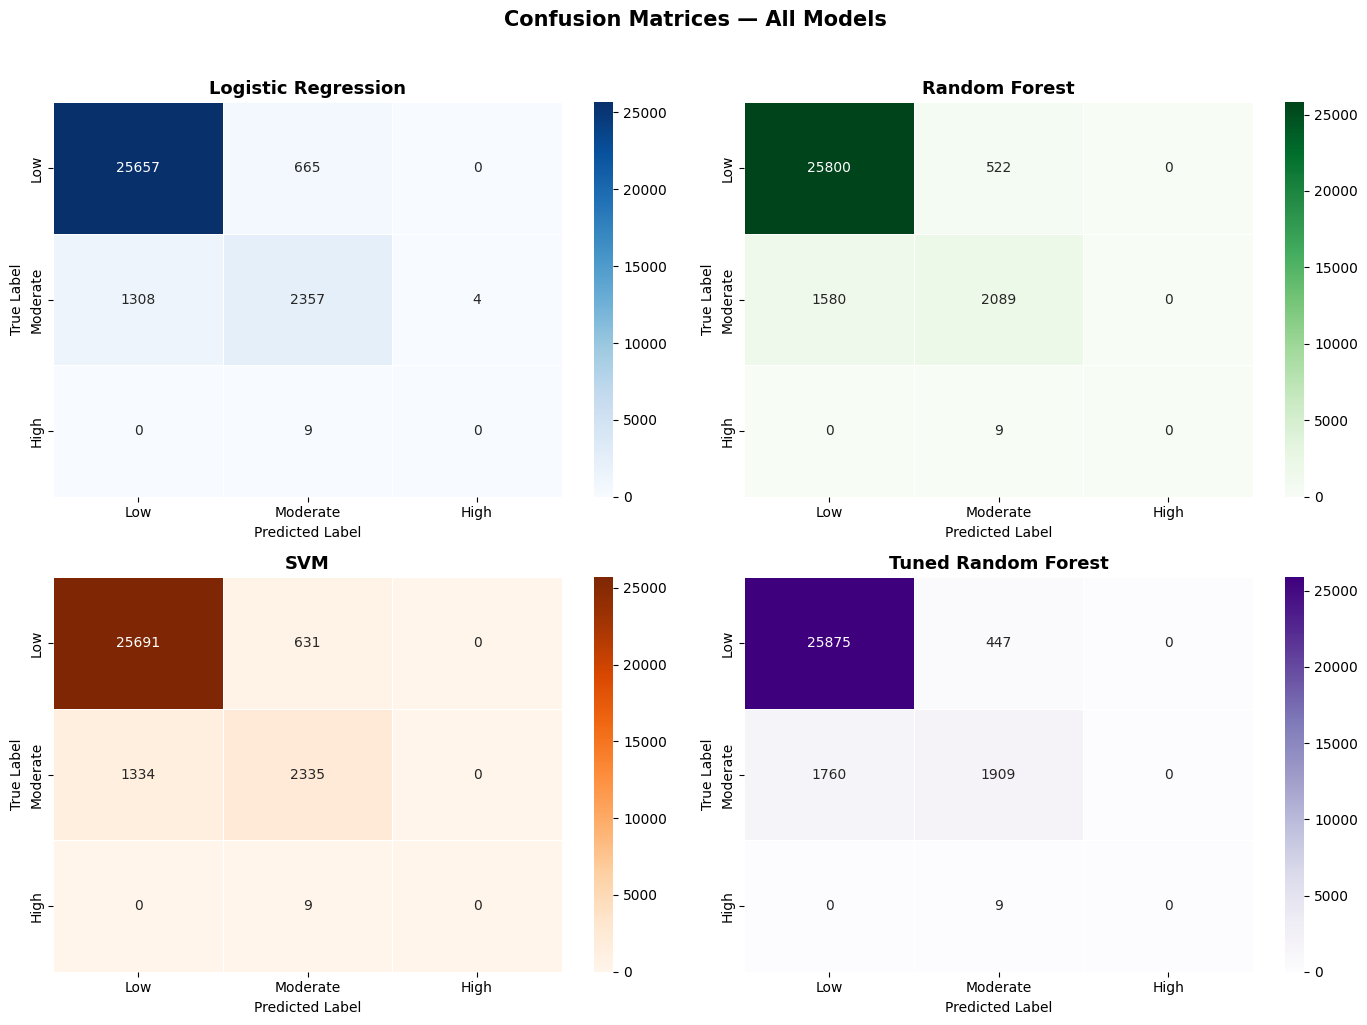

 Saved: confusion_matrices.png

Step 3: Model Comparison Chart


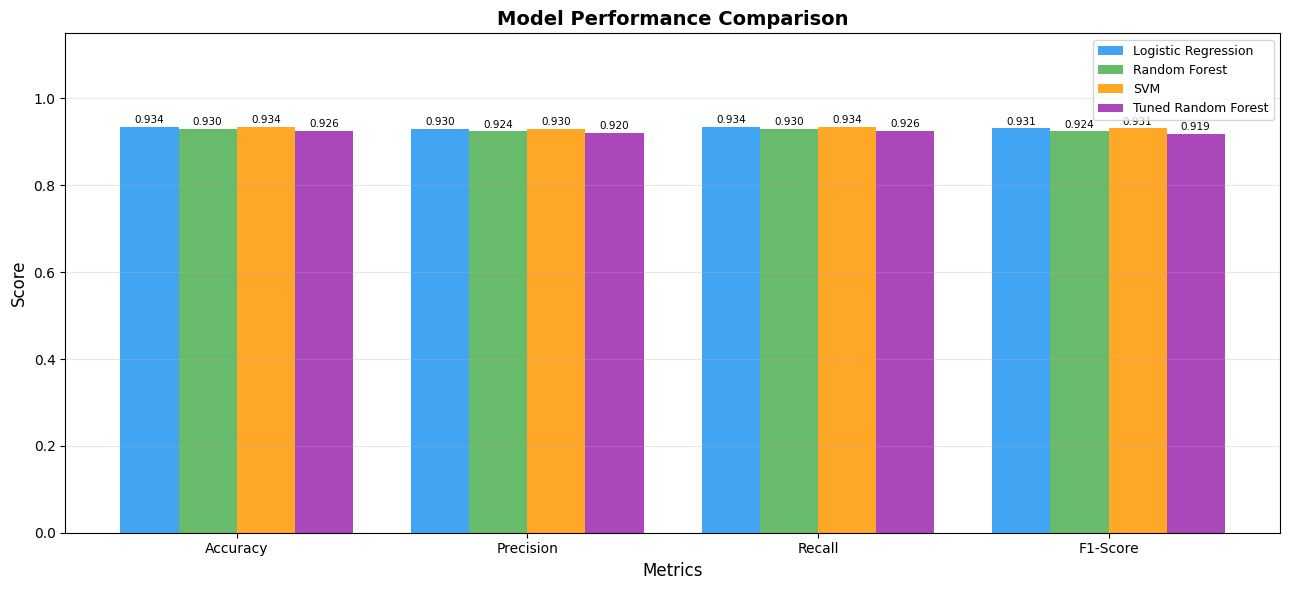

 Saved: model_comparison.png

Step 4: Best Model Selection

   Best Model  : Logistic Regression
     Accuracy    : 0.9338
     Precision   : 0.9299
     Recall      : 0.9338
     F1-Score    : 0.9310

  Justification:
  The best model was selected based on the highest weighted F1-Score,
  which balances Precision and Recall across all three burnout classes.
  This metric is preferred over plain Accuracy because the dataset is
  heavily imbalanced (Low >> Moderate >> High). The removal of the
  'burnout_score' column eliminated data leakage, making these results
  a true reflection of the model's generalization ability.



In [16]:
# ============================================================
# STUDENT 4 — Evaluation & Ethics Lead
# CCDS 322 - Applied Machine Learning Project
# ⚠️ Run this cell AFTER Student 3's cell
# ============================================================

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def show_step(title):
    print("\n" + "=" * 55)
    print(title)
    print("=" * 55)

# ── المتغيرات من كود زميلة 3 ──────────────────────────────
# log_pred, rf_pred, svm_pred, rf_tuned_pred, y_test
# ──────────────────────────────────────────────────────────

models_info = {
    "Logistic Regression" : log_pred,
    "Random Forest"       : rf_pred,
    "SVM"                 : svm_pred,
    "Tuned Random Forest" : rf_tuned_pred
}

class_names = ['Low', 'Moderate', 'High']

# ──────────────────────────────────────────────────────────
# STEP 1 — Detailed Performance Metrics
# ──────────────────────────────────────────────────────────
show_step("Step 1: Detailed Performance Metrics")

results = {}

for model_name, preds in models_info.items():
    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, average='weighted', zero_division=0)
    rec  = recall_score(y_test, preds,    average='weighted', zero_division=0)
    f1   = f1_score(y_test, preds,        average='weighted', zero_division=0)

    results[model_name] = {
        "Accuracy" : round(acc,  4),
        "Precision": round(prec, 4),
        "Recall"   : round(rec,  4),
        "F1-Score" : round(f1,   4)
    }

    print(f"\n{'─'*40}")
    print(f"  {model_name}")
    print(f"{'─'*40}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {prec:.4f}")
    print(f"  Recall    : {rec:.4f}")
    print(f"  F1-Score  : {f1:.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_test, preds, target_names=class_names, zero_division=0))

# ──────────────────────────────────────────────────────────
# STEP 2 — Confusion Matrices (4 في صورة واحدة)
# ──────────────────────────────────────────────────────────
show_step("Step 2: Confusion Matrices")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes   = axes.flatten()
colors = ['Blues', 'Greens', 'Oranges', 'Purples']

for i, (model_name, preds) in enumerate(models_info.items()):
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap=colors[i],
        xticklabels=class_names,
        yticklabels=class_names,
        ax=axes[i],
        linewidths=0.5
    )
    axes[i].set_title(model_name, fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Predicted Label', fontsize=10)
    axes[i].set_ylabel('True Label',      fontsize=10)

plt.suptitle('Confusion Matrices — All Models', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: confusion_matrices.png")

# ──────────────────────────────────────────────────────────
# STEP 3 — Model Comparison Bar Chart
# ──────────────────────────────────────────────────────────
show_step("Step 3: Model Comparison Chart")

metrics_labels = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
model_names    = list(results.keys())
x              = np.arange(len(metrics_labels))
width          = 0.2
bar_colors     = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, color) in enumerate(zip(model_names, bar_colors)):
    values = [results[model_name][m] for m in metrics_labels]
    bars   = ax.bar(x + i * width, values, width, label=model_name,
                    color=color, alpha=0.85)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.004,
            f'{bar.get_height():.3f}',
            ha='center', va='bottom', fontsize=7.5
        )

ax.set_xlabel('Metrics', fontsize=12)
ax.set_ylabel('Score',   fontsize=12)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(metrics_labels)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: model_comparison.png")

# ──────────────────────────────────────────────────────────
# STEP 4 — Best Model Selection
# ──────────────────────────────────────────────────────────
show_step("Step 4: Best Model Selection")

best_model_name = max(results, key=lambda m: results[m]['F1-Score'])
best            = results[best_model_name]

print(f"\n   Best Model  : {best_model_name}")
print(f"     Accuracy    : {best['Accuracy']:.4f}")
print(f"     Precision   : {best['Precision']:.4f}")
print(f"     Recall      : {best['Recall']:.4f}")
print(f"     F1-Score    : {best['F1-Score']:.4f}")
print("""
  Justification:
  The best model was selected based on the highest weighted F1-Score,
  which balances Precision and Recall across all three burnout classes.
  This metric is preferred over plain Accuracy because the dataset is
  heavily imbalanced (Low >> Moderate >> High). The removal of the
  'burnout_score' column eliminated data leakage, making these results
  a true reflection of the model's generalization ability.
""")